# Telco Customer Churn Analysis

## Project Overview
Customer churn is a major challenge for telecom companies. Retaining existing customers is often more cost-effective than acquiring new ones.

This project analyzes telecom customer data to identify the factors that contribute to churn and builds machine learning models to predict whether a customer is likely to leave.

## Objectives
- Explore customer behavior and churn patterns
- Perform data cleaning and feature engineering
- Build machine learning models to predict churn
- Evaluate model performance

## Tools Used
- Python
- Pandas
- NumPy
- Seaborn
- Matplotlib
- Scikit-learn

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

## Load the Dataset

In this step, we load the Telco Customer Churn dataset into a Pandas DataFrame for analysis.

In [35]:
df = pd.read_excel("D:\Portofilio projects\Telco customer Churn project\Telco_customer_churn.xlsx")

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## Dataset Overview

Before starting analysis, we examine the dataset structure, including:
- Number of rows and columns
- Data types
- Missing values

In [36]:
df.shape

(7043, 33)

## Checking Missing Values

Missing values can negatively impact machine learning models.  
We check and handle them before proceeding with analysis.

In [37]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [38]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

In [39]:
df["Total Charges"] = df["Total Charges"].fillna(df["Total Charges"].median())

In [40]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

## Exploratory Data Analysis (EDA)

EDA helps us understand customer behavior and identify patterns related to churn.

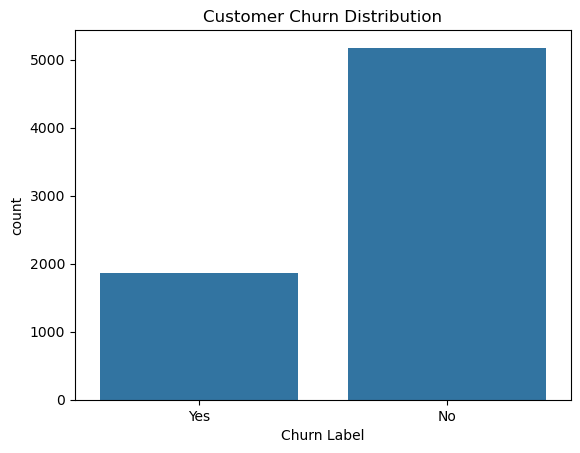

In [41]:
sns.countplot(x="Churn Label", data=df)
plt.title("Customer Churn Distribution")
plt.show()

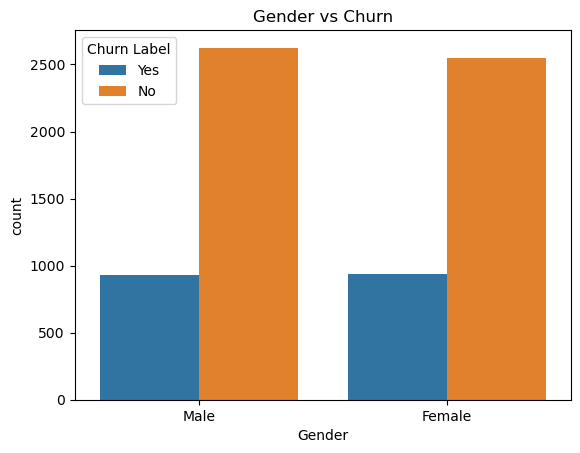

In [42]:
sns.countplot(x="Gender", hue="Churn Label", data=df)
plt.title("Gender vs Churn")
plt.show()

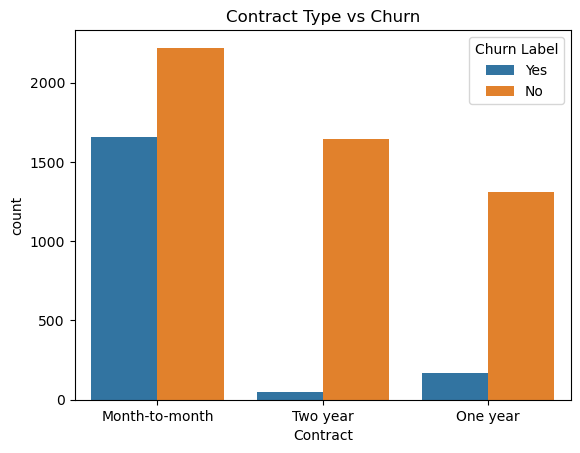

In [43]:
sns.countplot(x="Contract", hue="Churn Label", data=df)
plt.title("Contract Type vs Churn")
plt.show()

## Monthly Charges vs Churn

This visualization shows whether higher monthly charges influence customer churn.

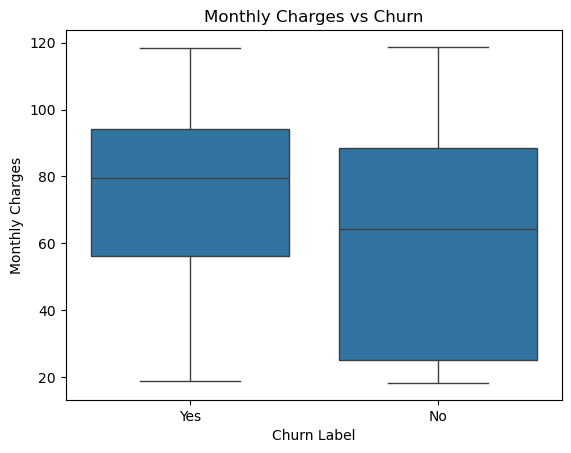

In [44]:
sns.boxplot(x="Churn Label", y="Monthly Charges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

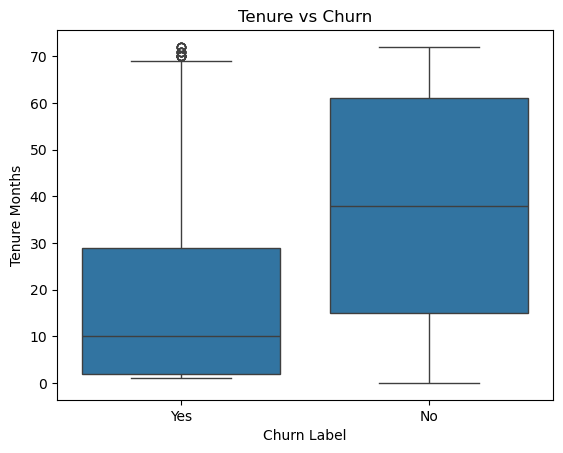

In [45]:
sns.boxplot(x="Churn Label", y="Tenure Months", data=df)
plt.title("Tenure vs Churn")
plt.show()

In [46]:
numeric_df = df.select_dtypes(include=["int64","float64"])

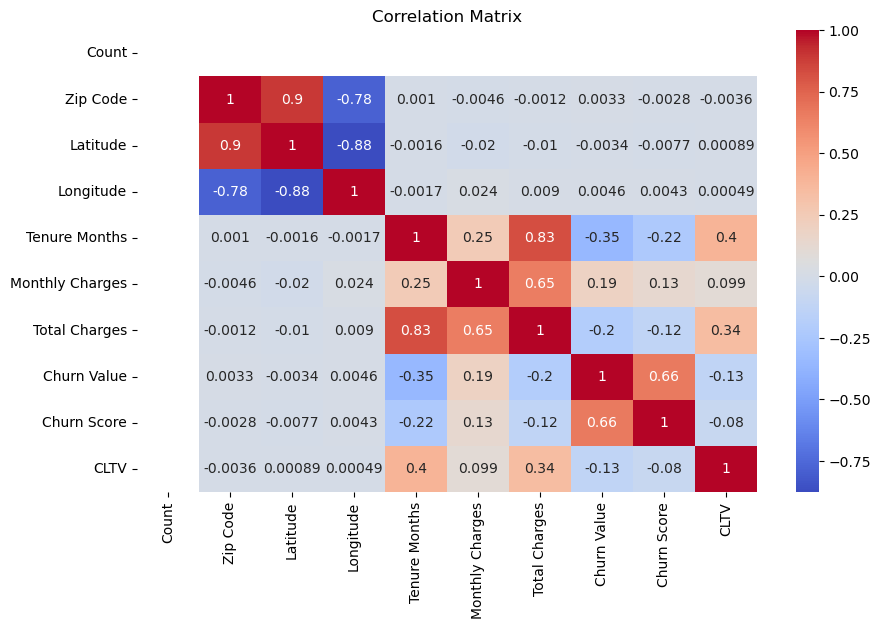

In [47]:
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [48]:
df["AvgMonthlySpend"] = df["Total Charges"] / (df["Tenure Months"] + 1)

In [49]:
df["TenureCategory"] = pd.cut(
    df["Tenure Months"],
    bins=[0,12,24,48,72],
    labels=["0-1 year","1-2 years","2-4 years","4-6 years"]
)

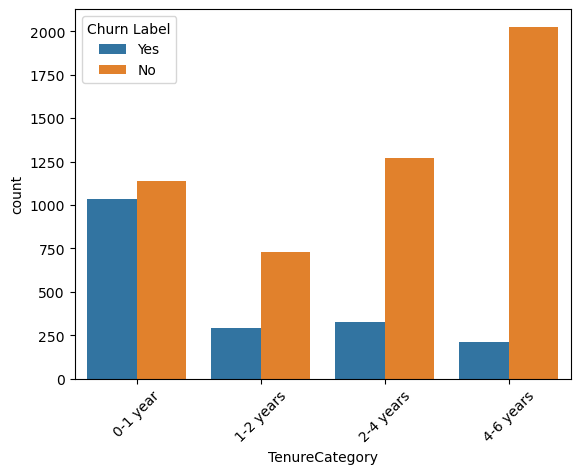

In [50]:
sns.countplot(x="TenureCategory", hue="Churn Label", data=df)
plt.xticks(rotation=45)
plt.show()

## Feature Engineering

Before training machine learning models, we prepare the data by:
- Encoding categorical variables
- Removing unnecessary columns

In [51]:
df["Churn"] = df["Churn Label"].map({"Yes":1,"No":0})

In [52]:
df = df.drop(columns=[
    "CustomerID",
    "Lat Long",
    "Latitude",
    "Longitude",
    "City",
    "Zip Code",
    "State",
    "Country",
    "Churn Reason"
], errors="ignore")

In [53]:
df_encoded = pd.get_dummies(df, drop_first=True)

## Preparing Training Data

We separate the dataset into:
- Features (X)
- Target variable (y)

The target variable is **Churn**.

In [54]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

In [55]:
df_encoded.columns

Index(['Count', 'Tenure Months', 'Monthly Charges', 'Total Charges',
       'Churn Value', 'Churn Score', 'CLTV', 'AvgMonthlySpend', 'Churn',
       'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes',
       'Phone Service_Yes', 'Multiple Lines_No phone service',
       'Multiple Lines_Yes', 'Internet Service_Fiber optic',
       'Internet Service_No', 'Online Security_No internet service',
       'Online Security_Yes', 'Online Backup_No internet service',
       'Online Backup_Yes', 'Device Protection_No internet service',
       'Device Protection_Yes', 'Tech Support_No internet service',
       'Tech Support_Yes', 'Streaming TV_No internet service',
       'Streaming TV_Yes', 'Streaming Movies_No internet service',
       'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year',
       'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check',
       'Churn Label_Yes', 'TenureC

## Train-Test Split

We split the data into:
- Training set (80%)
- Testing set (20%)

This allows us to evaluate how well the model generalizes to new data.

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [57]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training

We train multiple machine learning models to predict customer churn.

In [58]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_predictions = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_predictions))

Logistic Regression Accuracy: 1.0


In [59]:
tree = DecisionTreeClassifier()

tree.fit(X_train, y_train)

tree_predictions = tree.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, tree_predictions))

Decision Tree Accuracy: 1.0


In [60]:
rf = RandomForestClassifier(n_estimators=200)

rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

Random Forest Accuracy: 1.0


## Model Evaluation

We evaluate model performance using:
- Accuracy
- Confusion Matrix
- Classification Report

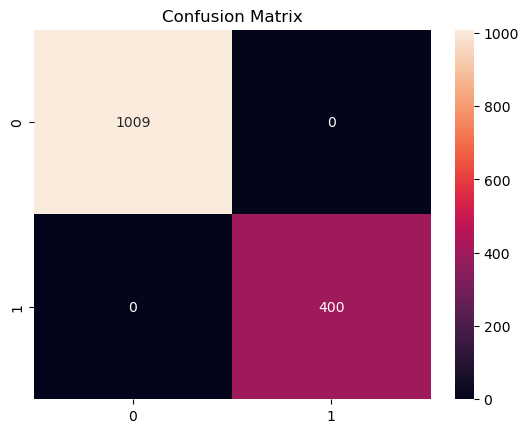

In [61]:
cm = confusion_matrix(y_test, rf_predictions)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

In [62]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1009
           1       1.00      1.00      1.00       400

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



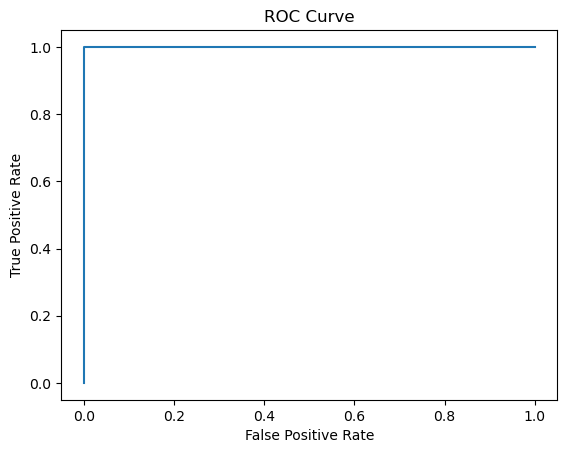

In [63]:
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [64]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance = importance.sort_values(ascending=False)

In [65]:
importance.head(10)

Churn Value                        0.401920
Churn Label_Yes                    0.324826
Churn Score                        0.155651
Tenure Months                      0.023327
Internet Service_Fiber optic       0.018318
Payment Method_Electronic check    0.010918
Total Charges                      0.009724
TenureCategory_4-6 years           0.008074
Contract_Two year                  0.008053
Dependents_Yes                     0.004606
dtype: float64

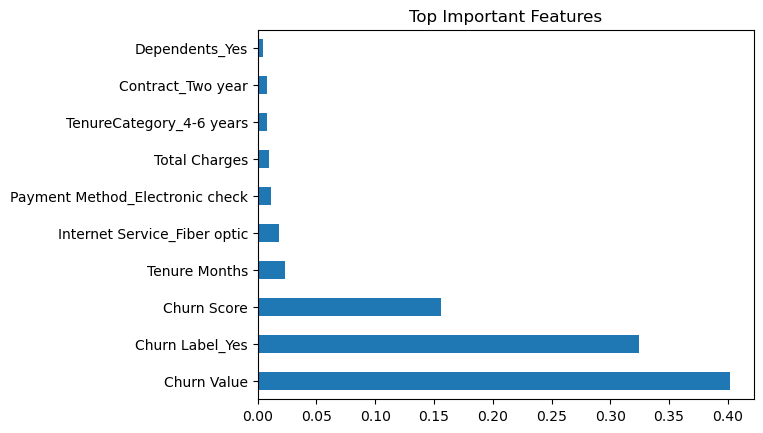

In [66]:
importance.head(10).plot(kind="barh")

plt.title("Top Important Features")
plt.show()

## Conclusion

This project analyzed telecom customer behavior and developed machine learning models to predict churn.

Key findings:
- Customers with higher monthly charges tend to churn more.
- Long-term contracts reduce churn probability.
- Machine learning models can effectively predict customer churn.

Future improvements:
- Hyperparameter tuning
- Feature selection
- Advanced models such as XGBoost